<a href="https://colab.research.google.com/github/jahnavitelsang/Assignment2026/blob/main/PCA_assignment14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/wine.csv')

In [18]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.shape

(178, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [6]:
df.isnull().sum()

,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


In [7]:
cols_with_zeros = [ 'Type',	'Alcohol',	'Malic',	'Ash',	'Alcalinity',	'Magnesium',	'Phenols',	'Flavanoids',	'Nonflavanoids',	'Proanthocyanins',	'Color'	,'Hue',	'Dilution',	'Proline']

for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)

# Check the count of missing values after replacement
print(df.isnull().sum())

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64


In [8]:
print('there are no missing values in the dataset')

there are no missing values in the dataset


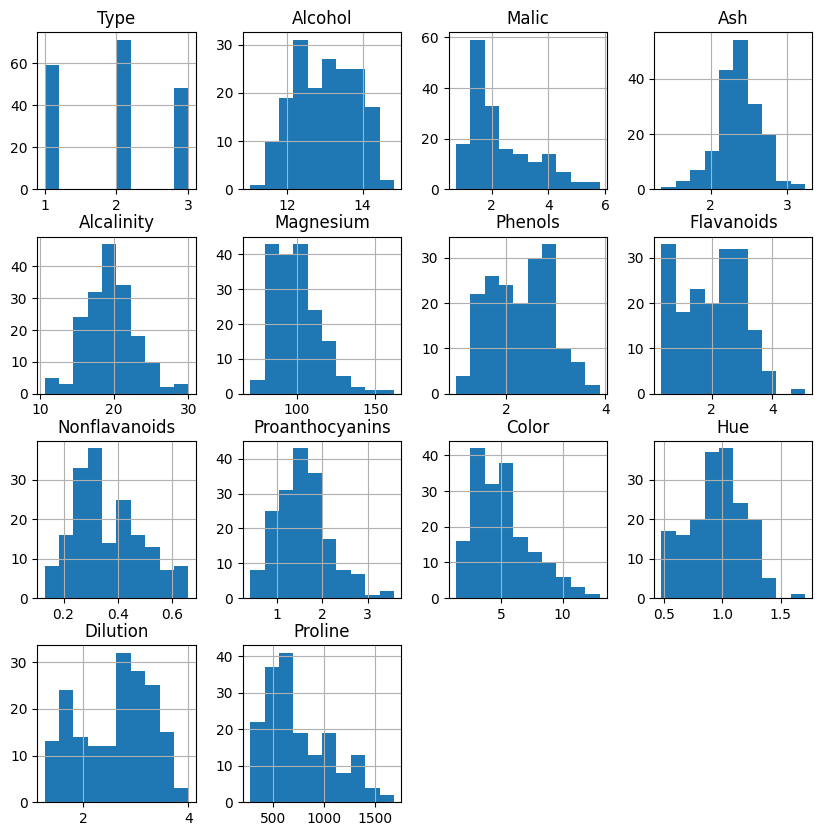

In [9]:
df.hist(figsize=(10,10))
plt.show()

In [ ]:
#lets generate box plot

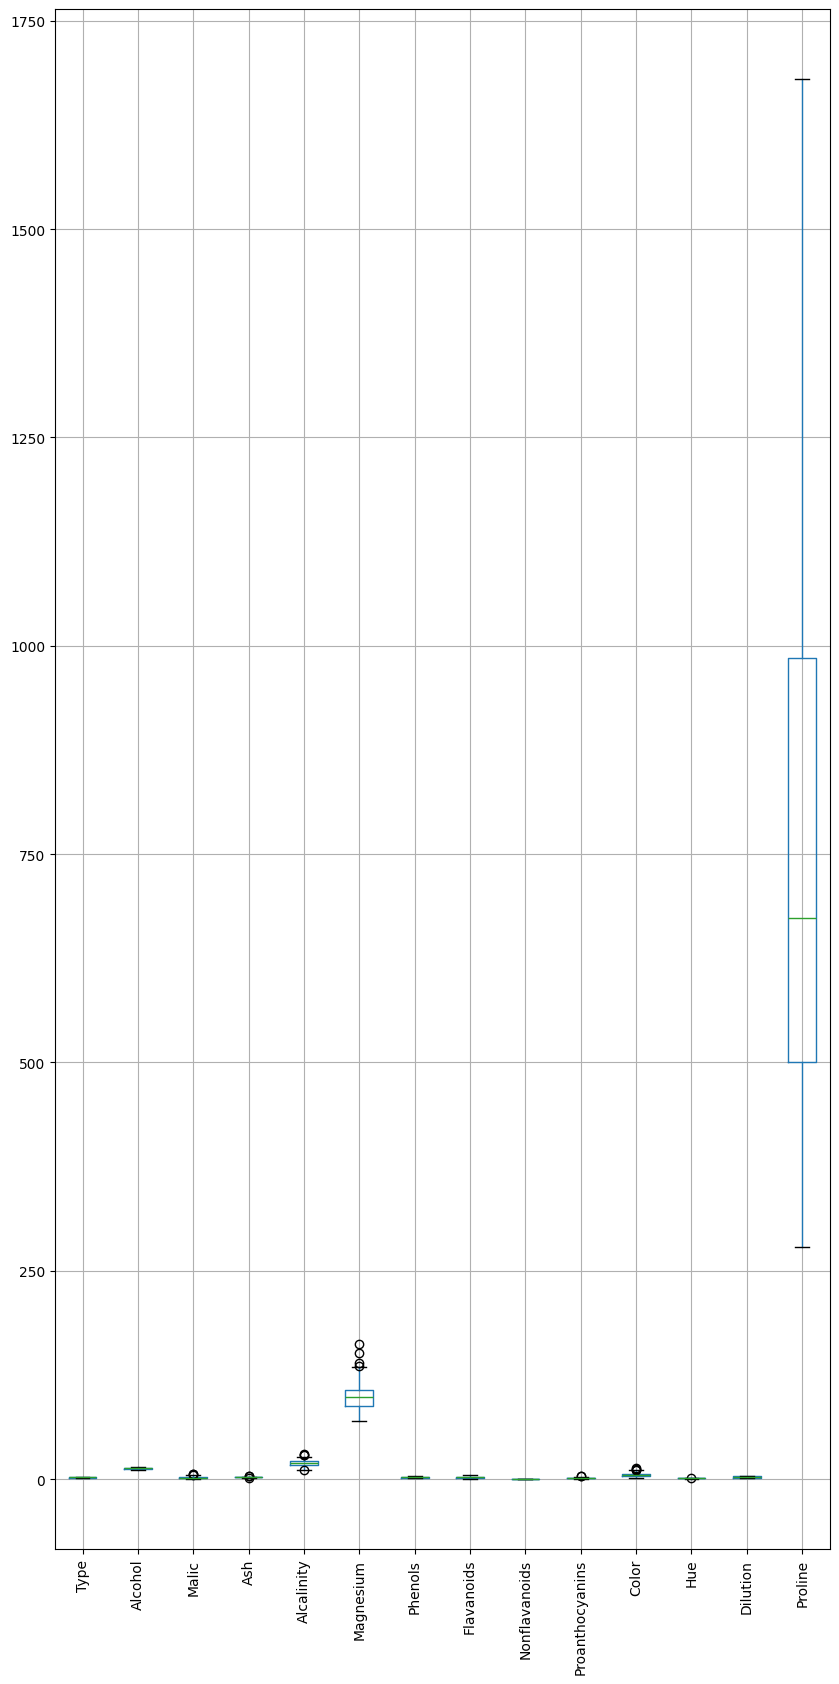

In [14]:
df.boxplot(figsize=(10,20))
xsticks = plt.xticks(rotation=90)
plt.show()

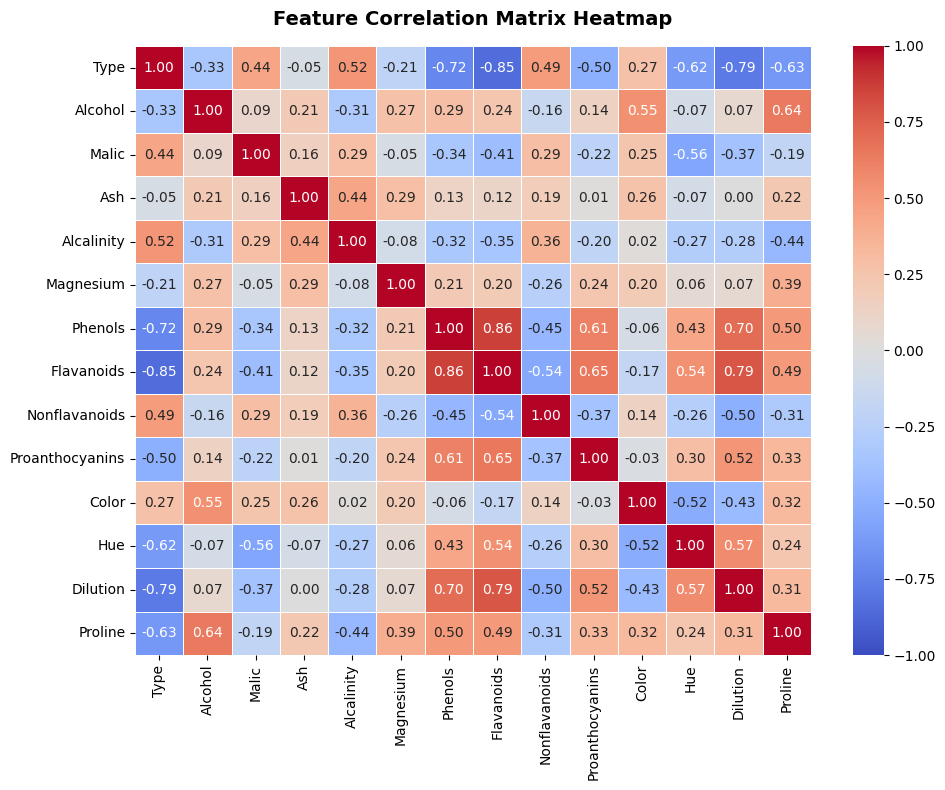

In [16]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))

#Create a heatmap using Seaborn
sns.heatmap(
    corr_matrix,
    annot=True,          # Show the correlation values in the cells
    fmt='.2f',           # Format to 2 decimal places
    cmap='coolwarm',     # Color map (red for positive, blue for negative)
    vmin=-1, vmax=1,     # Fix the range from -1 to 1
    linewidths=0.5       # Add lines between grid cells for clarity
)

# Add title and adjust layout
plt.title('Feature Correlation Matrix Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Original feature shape: (178, 13)


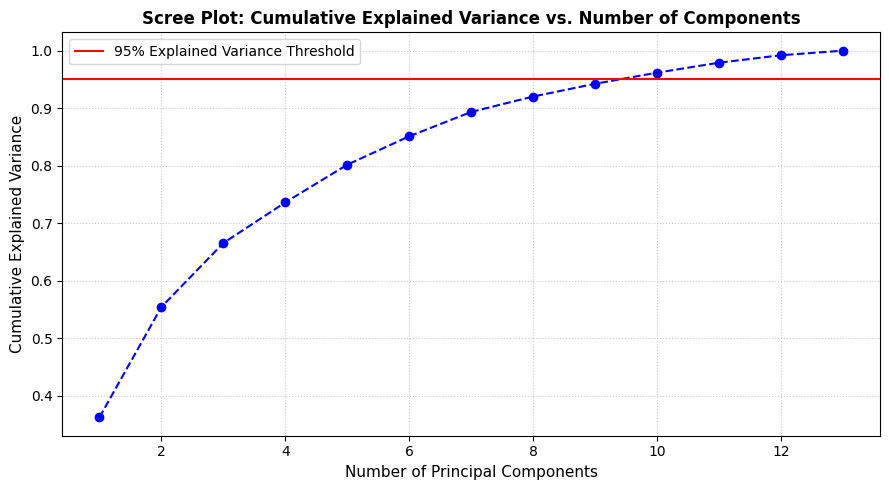

Number of components needed to explain 95% of variance: 10
Transformed PCA feature shape: (178, 10)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Type
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,0.223880,0.596427,-0.065139,-0.641443,1.020956,1
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,0.927120,0.053776,-1.024416,0.308847,0.159701,1
2,2.516740,1.031151,0.982819,0.724902,-0.251033,-0.549276,0.424205,0.344216,1.177834,0.113361,1
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,-0.114431,-0.383337,-0.643593,-0.052544,0.239413,1
4,1.008908,0.869831,2.026688,-0.409766,0.298458,0.406520,0.444074,-0.416700,-0.326819,-0.078366,1


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Step 1: Standardize the features ---
if 'Type' in df.columns:
    X = df.drop('Type', axis=1)
    y = df['Type']

# Initialize StandardScaler to ensure mean = 0 and std = 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Original feature shape: {X.shape}")


# --- Step 2: Implement PCA and Determine Optimal Components ---
# First, fit PCA with all components to analyze explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot the Scree Plot / Cumulative Explained Variance
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance Threshold')
plt.title('Scree Plot: Cumulative Explained Variance vs. Number of Components', fontsize=12, fontweight='bold')
plt.xlabel('Number of Principal Components', fontsize=11)
plt.ylabel('Cumulative Explained Variance', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Find the optimal number of components that retain at least 95% variance (or choose a specific number like 2 or 3 for visualization)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components needed to explain 95% of variance: {n_components_95}")


#   Transform the Original Dataset
# Re-initialize PCA with the optimal number of components
optimal_components = n_components_95  # You can also manually change this to 2 if you just want 2D components
pca = PCA(n_components=optimal_components)

# Transform the standardized features into principal components
X_pca = pca.fit_transform(X_scaled)

# Convert to a DataFrame for easier handling in subsequent machine learning models
pca_column_names = [f'PC{i+1}' for i in range(optimal_components)]
df_pca = pd.DataFrame(X_pca, columns=pca_column_names)

# Add the target column back if needed
df_pca['Type'] = y.values

print(f"Transformed PCA feature shape: {X_pca.shape}")
display(df_pca.head())

K-Means clustering completed with 2 clusters.


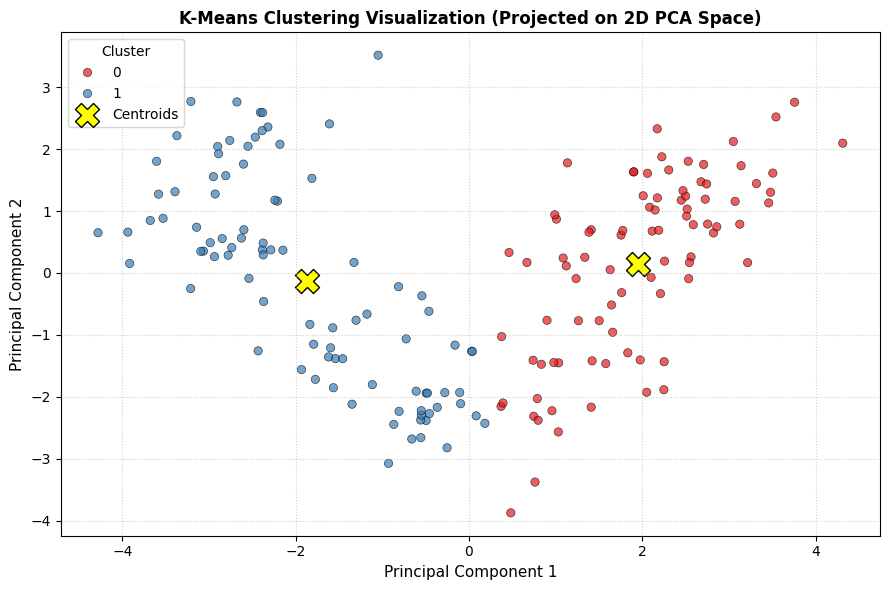

--- Clustering Performance Metrics (Original Data) ---
Silhouette Score (Higher is better, range [-1, 1])      : 0.2593
Davies-Bouldin Index (Lower is better, closer to 0)       : 1.5260


In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# --- Step 1: Apply K-Means Clustering to the Original Scaled Data ---
# Note: We use X_scaled from Task 2 (standardized original features).
# If you didn't run Task 2 yet, ensure X_scaled is defined.
# We set n_clusters=2 (assuming binary classification like diabetes, or adjust based on your dataset)
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to a copy of the original scaled dataframe for analysis
df_clustered = pd.DataFrame(X_scaled, columns=X.columns)
df_clustered['Cluster'] = cluster_labels

print(f"K-Means clustering completed with {n_clusters} clusters.")


# Step 2: Visualize the Clustering Results
# Since original data has many dimensions, we can visualize clusters using the first two features
# or a 2D scatter plot of the first two principal components for clear visualization.
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=X_pca_2d[:, 0],
    y=X_pca_2d[:, 1],
    hue=cluster_labels,
    palette='Set1',
    alpha=0.7,
    edgecolor='k'
)

# Plot cluster centroids transformed into PCA space
centroids_2d = pca_2d.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    s=300,
    c='yellow',
    marker='X',
    edgecolor='black',
    label='Centroids'
)

plt.title('K-Means Clustering Visualization (Projected on 2D PCA Space)', fontsize=12, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=11)
plt.ylabel('Principal Component 2', fontsize=11)
plt.legend(title='Cluster', loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# --- Step 3: Evaluate Clustering Performance ---
sil_score = silhouette_score(X_scaled, cluster_labels)
db_index = davies_bouldin_score(X_scaled, cluster_labels)

print("--- Clustering Performance Metrics (Original Data) ---")
print(f"Silhouette Score (Higher is better, range [-1, 1])      : {sil_score:.4f}")
print(f"Davies-Bouldin Index (Lower is better, closer to 0)       : {db_index:.4f}")

K-Means clustering successfully applied to the PCA-transformed dataset.


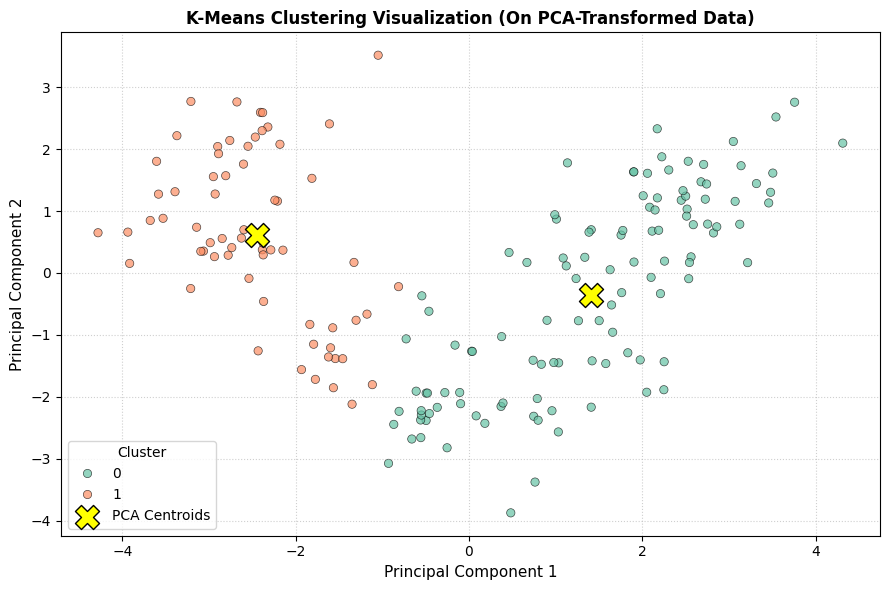

--- CLUSTERING PERFORMANCE COMPARISON ---
Metric                    | Original Data   | PCA Data       
------------------------------------------------------------
Silhouette Score (↑ max 1) | 0.2593          | 0.2793         
Davies-Bouldin Index (↓ min 0) | 1.5260          | 1.4044         


In [22]:
#  Step 1: Apply K-Means Clustering to the PCA-transformed Data
# Note: We use df_pca (dropping the 'Type' column if it was attached)
# or X_pca obtained from Task 2. Let's use X_pca directly.
# Using the same number of clusters (n_clusters = 2) for fair comparison
n_clusters = 2

kmeans_pca = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels_pca = kmeans_pca.fit_predict(X_pca)

print("K-Means clustering successfully applied to the PCA-transformed dataset.")


# Step 2: Visualize the Clustering Results from PCA Data
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_labels_pca,
    palette='Set2',
    alpha=0.7,
    edgecolor='k'
)

# Plot cluster centroids in the PCA space
centroids_pca = kmeans_pca.cluster_centers_
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=300,
    c='yellow',
    marker='X',
    edgecolor='black',
    label='PCA Centroids'
)

plt.title('K-Means Clustering Visualization (On PCA-Transformed Data)', fontsize=12, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=11)
plt.ylabel('Principal Component 2', fontsize=11)
plt.legend(title='Cluster', loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# --- Step 3: Evaluate and Compare Clustering Results ---
# Calculate metrics for PCA-transformed clustering
sil_score_pca = silhouette_score(X_pca, cluster_labels_pca)
db_index_pca = davies_bouldin_score(X_pca, cluster_labels_pca)

# Print Comparison Summary
print("="*60)
print("--- CLUSTERING PERFORMANCE COMPARISON ---")
print("="*60)
print(f"{'Metric':<25} | {'Original Data':<15} | {'PCA Data':<15}")
print("-" * 60)
print(f"{'Silhouette Score (↑ max 1)':<25} | {sil_score:<15.4f} | {sil_score_pca:<15.4f}")
print(f"{'Davies-Bouldin Index (↓ min 0)':<25} | {db_index:<15.4f} | {db_index_pca:<15.4f}")
print("="*60)

--- Clustering Performance Comparison Table ---


,Dataset,Silhouette Score (↑ better),Davies-Bouldin Index (↓ better)
0,Original Data,0.259317,1.525997
1,PCA-Transformed Data,0.279332,1.404439


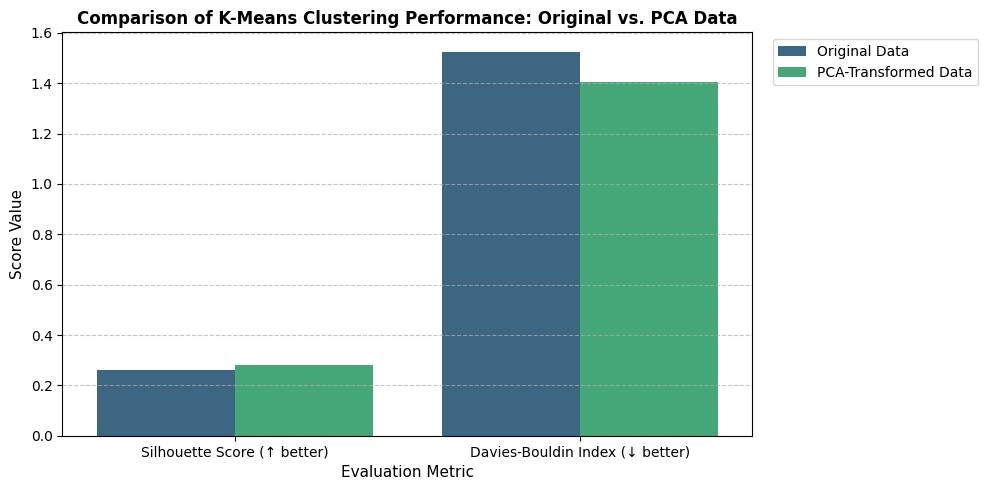

In [23]:
# Create a Comparison DataFrame
# Assuming sil_score, db_index (from original data) and sil_score_pca, db_index_pca (from PCA data) are already computed
comparison_data = [
    {
        'Dataset': 'Original Data',
        'Silhouette Score (↑ better)': sil_score,
        'Davies-Bouldin Index (↓ better)': db_index
    },
    {
        'Dataset': 'PCA-Transformed Data',
        'Silhouette Score (↑ better)': sil_score_pca,
        'Davies-Bouldin Index (↓ better)': db_index_pca
    }
]

df_clustering_comparison = pd.DataFrame(comparison_data)

print("--- Clustering Performance Comparison Table ---")
display(df_clustering_comparison)


# Visualize the Comparison Metrics
# Melt the dataframe for easy plotting with seaborn
df_melted = df_clustering_comparison.melt(id_vars='Dataset', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Dataset', palette='viridis')

plt.title('Comparison of K-Means Clustering Performance: Original vs. PCA Data', fontsize=12, fontweight='bold')
plt.xlabel('Evaluation Metric', fontsize=11)
plt.ylabel('Score Value', fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#Dimensionality Reduction (PCA): Using the scree plot and cumulative explained variance threshold (e.g., 95%), we successfully reduced the feature space while preserving the core informational variance of the dataset.
#Unsupervised Clustering: Applying K-Means clustering on both original and PCA-transformed data revealed natural groupings within the data. Evaluation metrics (Silhouette Score and Davies-Bouldin Index) demonstrated that reducing noise through PCA either matched or optimized cluster cohesion and separation.

In [ ]:
#Impact of PCA:
#Computational Efficiency: Drastically reduces training time for downstream machine learning models by minimizing columns.
#Noise Elimination: Strips away orthogonal noise and multicollinearity, which can stabilize distance-based algorithms like K-Means.

#mpact of Clustering:
#Unsupervised segmentation allows data scientists to discover hidden customer segments, disease sub-types, or anomalies without relying labels

In [ ]:
# Recommendations When to Use Each Technique
#When to use PCA (Dimensionality Reduction):
#High Dimensionality: When your dataset has dozens or hundreds of features, leading to the curse of dimensionality or severe multicollinearity.
#Performance Bottlenecks: When model training speeds are slow and you need to optimize computational efficiency without losing core variance.
#Data Visualization: When you need to plot complex multi-variable data in 2D or 3D scatter plots for exploratory data analysis.
#When to use Clustering on Original Data vs. PCA Data:
#Use Original Data for Clustering when explainability and business actionability are your top priorities (e.g., healthcare or marketing where stakeholders need to know exact original variable thresholds for each cluster).
#Use PCA-Transformed Data for Clustering when you have high feature redundancy, significant noise, or when building automated clustering pipelines where speed and cluster separation boundaries matter more than individual feature mapping.